In [13]:
import sys
sys.path.append("..")
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
from datasets import load_from_disk
from torch.utils.data import DataLoader

In [2]:
# Загрузка модели, корневая папка проекта
from src.data import PROJECT_ROOT, load_model_and_tokenizer, RuleTakerDataset, estimate_max_length, create_minimal_pairs, compute_differential_stats, analyze_neuron_activations
from src.probing import run_probing_experiment, load_probing_results
from src.llm_upgrade import wrap_for_transformer_lens

In [4]:
sns.set_style("whitegrid")

In [5]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/probing"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по зондированию на GPT-2 Large

## Эксперимент 6-1: GPT-2 Large (QLoRA) + depth-0

In [6]:
# Параметры эксперимента
VARIANT = "depth-0"
MODEL_SIZE = "gpt2-large"
BASE_MODEL_NAME = "gpt2-large"
ADAPTER_PATH = PROJECT_ROOT / "results/checkpoints/finetune/exp6-1/checkpoint-11000"
USE_SMALL = True
HOOK_NAME = "resid_post"
POOLING = "last"
BATCH_SIZE = 8

### Подготовка модели и данных

In [7]:
hooked_model, tokenizer = wrap_for_transformer_lens(
    base_model_name=BASE_MODEL_NAME,
    adapter_path=str(ADAPTER_PATH),
    device="cuda"
)
hooked_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\peft\tuners\lora\layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Loaded pretrained model gpt2-large into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-35): 36 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hook_re

In [8]:
# Загружаем усеченную версию датасета
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))

In [9]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 184 токенов (при макс длине 226)


In [10]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [11]:
MAX_LENGTH = max_p95

In [12]:
train_dataset = RuleTakerDataset(dataset["train"], tokenizer, max_length=MAX_LENGTH)
dev_dataset = RuleTakerDataset(dataset["dev"], tokenizer, max_length=MAX_LENGTH)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Метод probing classifiers

In [15]:
n_layers = hooked_model.cfg.n_layers
d_model = hooked_model.cfg.d_model

In [16]:
n_layers

36

In [17]:
torch.cuda.empty_cache()

In [18]:
# Кэшируем активации
results = run_probing_experiment(
    hooked_model, train_loader, dev_loader, n_layers,
    hook_name=HOOK_NAME, pooling=POOLING
)

Probing layers:   0%|          | 0/36 [00:00<?, ?it/s]

Probing layers:  58%|█████▊    | 21/36 [33:02<24:01, 96.10s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Probing layers:  61%|██████    | 22/36 [34:39<22:27, 96.25s/it]c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the con

In [19]:
# Извлечение данных для графиков
train_accs = results["train_accs"]
dev_accs = results["dev_accs"]
train_means = [s["mean_abs"] for s in results["train_stats"]]
dev_means = [s["mean_abs"] for s in results["dev_stats"]]
train_stds = [s["std_abs"] for s in results["train_stats"]]
dev_stds = [s["std_abs"] for s in results["dev_stats"]]
train_sparsity = [s["sparsity"] for s in results["train_stats"]]
dev_sparsity = [s["sparsity"] for s in results["dev_stats"]]

In [20]:
# Визуализация результатов
best_layer = int(np.argmax(dev_accs))
best_train_acc = float(train_accs[best_layer])
best_dev_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer} (0-based), Dev Accuracy: {best_dev_acc:.4f}")

Лучший слой: 34 (0-based), Dev Accuracy: 0.5500


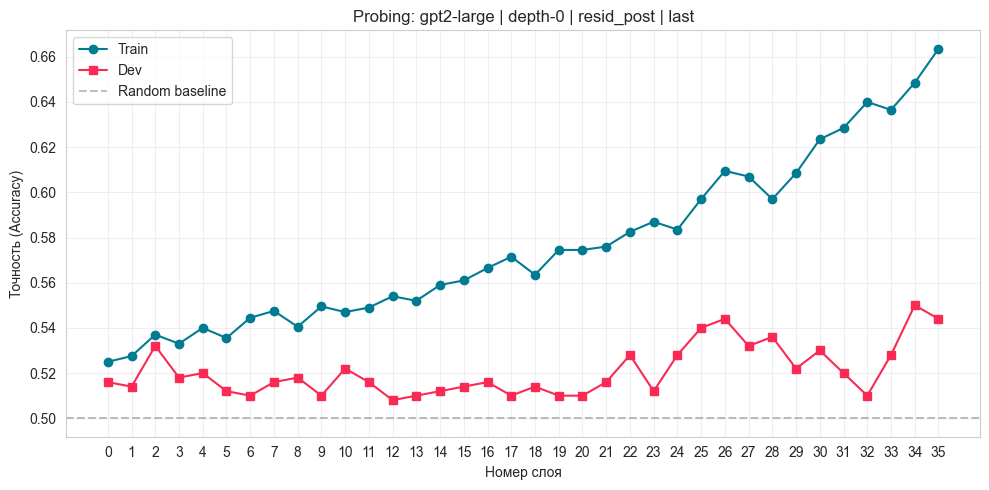

In [21]:
plt.figure(figsize=(10, 5))
x = np.arange(n_layers)
plt.plot(x, train_accs, marker="o", label="Train", color="xkcd:ocean")
plt.plot(x, dev_accs, marker="s", label="Dev", color="xkcd:red pink")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
plt.xlabel("Номер слоя")
plt.ylabel("Точность (Accuracy)")
plt.title(f"Probing: {MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING}")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

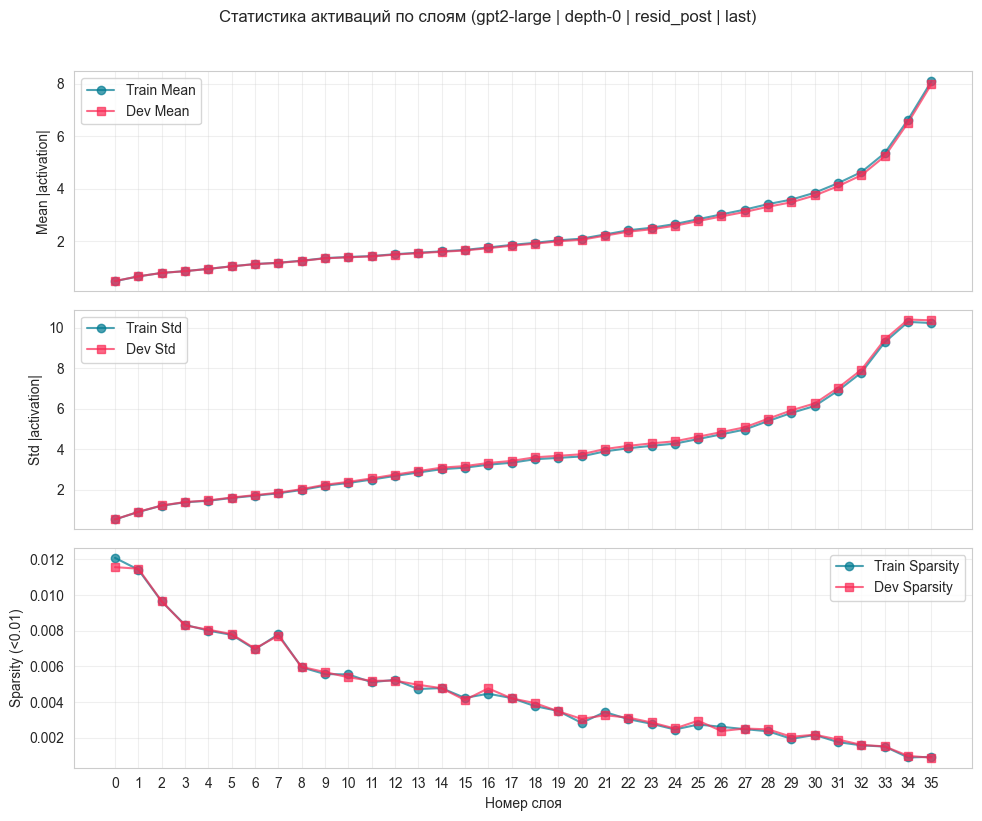

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(x, train_means, marker="o", label="Train Mean", color="xkcd:ocean", alpha=0.7)
ax1.plot(x, dev_means, marker="s", label="Dev Mean", color="xkcd:red pink", alpha=0.7)
ax1.set_ylabel("Mean |activation|")
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x, train_stds, marker="o", label="Train Std", color="xkcd:ocean", alpha=0.7)
ax2.plot(x, dev_stds, marker="s", label="Dev Std", color="xkcd:red pink", alpha=0.7)
ax2.set_ylabel("Std |activation|")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x, train_sparsity, marker="o", label="Train Sparsity", color="xkcd:ocean", alpha=0.7)
ax3.plot(x, dev_sparsity, marker="s", label="Dev Sparsity", color="xkcd:red pink", alpha=0.7)
ax3.set_ylabel("Sparsity (<0.01)")
ax3.set_xlabel("Номер слоя")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f"Статистика активаций по слоям ({MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING})", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Сохранение метрик в JSON
fname = f"probe_{MODEL_SIZE}(QLoRA)_{VARIANT}_{HOOK_NAME}_{POOLING}.json"
fpath = RESULTS_DIR / fname

In [26]:
metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "best_layer": best_layer,
    "best_dev_acc": float(best_dev_acc),
    "train_accs": [float(a) for a in train_accs],
    "dev_accs": [float(a) for a in dev_accs]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "probing_layer_selection",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_train_acc": best_train_acc,
    "best_dev_acc": best_dev_acc,
    "n_layers": len(results["layers"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": results["layers"],
    "train_accs": [float(x) for x in results["train_accs"]],
    "dev_accs": [float(x) for x in results["dev_accs"]],
    "train_stats": results["train_stats"],
    "dev_stats": results["dev_stats"]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\probing\probe_gpt2-large(QLoRA)_depth-0_resid_post_last.json


### Проверка токенизации

In [27]:
# Список ключевых слов для проверки
logic_keywords = ["if", "then", "and", "or", "not", "implies", "is", "are", "all", "some", "no"]

In [28]:
# Возьмём несколько примеров из датасета (первые 3 из train)
sample_texts = list(dataset["train"]["text"])[:3]

In [29]:
for i, text in enumerate(sample_texts):
    print(f"Пример {i+1}:\n{text[:300]}...\n")  # первые 300 символов
    tokens = tokenizer.tokenize(text)
    print(f"Токены (первые 50): {tokens[:50]}\n")

    # Проверка каждого ключевого слова
    print("Наличие ключевых слов в тексте и токенах:")
    for kw in logic_keywords:
        in_text = kw in text.lower()
        # ищем токен, совпадающий с kw (без учёта регистра)
        in_tokens = any(tok.lstrip("Ġ").lower() == kw for tok in tokens)
        print(f"  '{kw}': в тексте={in_text}, в токенах={in_tokens}")
    print("-" * 80)

Пример 1:
Anne is blue. Anne is rough. Anne is young. All young people are cold. If someone is rough and nice then they are green. Rough people are young. If Anne is green then Anne is blue. If someone is rough and furry then they are blue. Cold people are rough. Anne is rough....

Токены (первые 50): ['Anne', 'Ġis', 'Ġblue', '.', 'ĠAnne', 'Ġis', 'Ġrough', '.', 'ĠAnne', 'Ġis', 'Ġyoung', '.', 'ĠAll', 'Ġyoung', 'Ġpeople', 'Ġare', 'Ġcold', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġnice', 'Ġthen', 'Ġthey', 'Ġare', 'Ġgreen', '.', 'ĠRough', 'Ġpeople', 'Ġare', 'Ġyoung', '.', 'ĠIf', 'ĠAnne', 'Ġis', 'Ġgreen', 'Ġthen', 'ĠAnne', 'Ġis', 'Ġblue', '.', 'ĠIf', 'Ġsomeone', 'Ġis', 'Ġrough', 'Ġand', 'Ġfurry', 'Ġthen']

Наличие ключевых слов в тексте и токенах:
  'if': в тексте=True, в токенах=True
  'then': в тексте=True, в токенах=True
  'and': в тексте=True, в токенах=True
  'or': в тексте=False, в токенах=False
  'not': в тексте=False, в токенах=False
  'implies': в тексте=False, в токенах=F

In [30]:
# Токенизация самих ключевых слов как отдельных строк
for kw in logic_keywords:
    tokens_kw = tokenizer.tokenize(kw)
    is_single = len(tokens_kw) == 1
    print(f"'{kw}' -> {tokens_kw} (цельный токен: {is_single})")

'if' -> ['if'] (цельный токен: True)
'then' -> ['then'] (цельный токен: True)
'and' -> ['and'] (цельный токен: True)
'or' -> ['or'] (цельный токен: True)
'not' -> ['not'] (цельный токен: True)
'implies' -> ['impl', 'ies'] (цельный токен: False)
'is' -> ['is'] (цельный токен: True)
'are' -> ['are'] (цельный токен: True)
'all' -> ['all'] (цельный токен: True)
'some' -> ['some'] (цельный токен: True)
'no' -> ['no'] (цельный токен: True)


### Разностный анализ активаций

In [33]:
data = load_probing_results(f"{MODEL_SIZE}(qLoRA)", VARIANT, HOOK_NAME, POOLING)

In [34]:
data

{'metadata': {'experiment_type': 'probing_layer_selection',
  'timestamp': '2026-05-15T15:30:10.627272',
  'variant': 'depth-0',
  'model_size': 'gpt2-large',
  'hook_name': 'resid_post',
  'pooling': 'last',
  'batch_size': 8,
  'max_length': 184},
 'summary': {'best_layer': 34,
  'best_train_acc': 0.6485,
  'best_dev_acc': 0.55,
  'n_layers': 36},
 'layers': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 'train_accs': [0.525,
  0.5275,
  0.537,
  0.533,
  0.54,
  0.5355,
  0.5445,
  0.5475,
  0.5405,
  0.5495,
  0.547,
  0.549,
  0.554,
  0.552,
  0.559,
  0.561,
  0.5665,
  0.5715,
  0.5635,
  0.5745,
  0.5745,
  0.576,
  0.5825,
  0.587,
  0.5835,
  0.597,
  0.6095,
  0.607,
  0.597,
  0.6085,
  0.6235,
  0.6285,
  0.64,
  0.6365,
  0.6485,
  0.6635],
 'dev_accs': [0.516,
  0.514,
  0.532,
  0.518,
  0.52,
  0.512,
  0.51,
 

In [35]:
DIFF_LAYER = data["summary"]["best_layer"]

In [36]:
pairs = create_minimal_pairs(variant=VARIANT, n_pairs=30)

In [37]:
diff_stats = compute_differential_stats(
    hooked_model, tokenizer, pairs,
    layer_idx=DIFF_LAYER,
    hook_name=HOOK_NAME,
    pooling=POOLING,
    max_length=data["metadata"]["max_length"]   # или из MAX_LENGTH
)

In [38]:
print(f"Средняя абсолютная разница активаций: {diff_stats['mean_abs_diff']:.4f}")
print(f"Стандартное отклонение разницы: {diff_stats['std_diff']:.4f}")

Средняя абсолютная разница активаций: 0.0556
Стандартное отклонение разницы: 0.0810


In [39]:
neuron_sens = diff_stats['neuron_sensitivity']
top_neurons = np.argsort(neuron_sens)[-100:][::-1]
print("Топ-100 нейронов с наибольшей средней разницей:")
for i, n in enumerate(top_neurons):
    print(f"  Нейрон {n}: {neuron_sens[n]:.4f}")

Топ-100 нейронов с наибольшей средней разницей:
  Нейрон 8: 0.8687
  Нейрон 440: 0.8667
  Нейрон 792: 0.6000
  Нейрон 870: 0.2417
  Нейрон 247: 0.2297
  Нейрон 24: 0.2042
  Нейрон 195: 0.1917
  Нейрон 486: 0.1771
  Нейрон 36: 0.1708
  Нейрон 623: 0.1333
  Нейрон 89: 0.1312
  Нейрон 105: 0.1312
  Нейрон 735: 0.1229
  Нейрон 1279: 0.1187
  Нейрон 215: 0.1185
  Нейрон 710: 0.1135
  Нейрон 737: 0.1125
  Нейрон 50: 0.1125
  Нейрон 974: 0.1115
  Нейрон 71: 0.1083
  Нейрон 468: 0.1078
  Нейрон 713: 0.1073
  Нейрон 1022: 0.1068
  Нейрон 1061: 0.1063
  Нейрон 273: 0.1042
  Нейрон 220: 0.1042
  Нейрон 1037: 0.1042
  Нейрон 45: 0.1036
  Нейрон 908: 0.1021
  Нейрон 248: 0.1005
  Нейрон 22: 0.1000
  Нейрон 919: 0.0997
  Нейрон 59: 0.0979
  Нейрон 230: 0.0969
  Нейрон 143: 0.0964
  Нейрон 939: 0.0961
  Нейрон 449: 0.0958
  Нейрон 625: 0.0958
  Нейрон 921: 0.0958
  Нейрон 1174: 0.0958
  Нейрон 131: 0.0953
  Нейрон 154: 0.0948
  Нейрон 750: 0.0948
  Нейрон 1016: 0.0938
  Нейрон 1099: 0.0922
  Нейрон 7

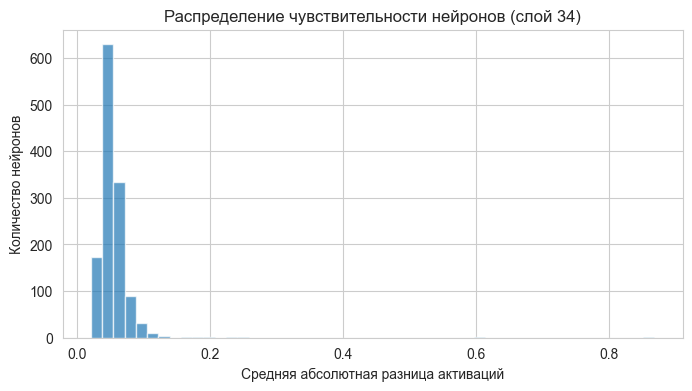

In [40]:
# Гистограмма чувствительности нейронов
plt.figure(figsize=(8,4))
plt.hist(neuron_sens, bins=50, alpha=0.7)
plt.xlabel("Средняя абсолютная разница активаций")
plt.ylabel("Количество нейронов")
plt.title(f"Распределение чувствительности нейронов (слой {DIFF_LAYER})")
plt.grid(True)
plt.show()

In [41]:
# Добавляем результаты разностного анализа в файл json с результатами пробинга
diff_stats["neuron_sensitivity"] = diff_stats["neuron_sensitivity"].tolist()
data["diff_stats"] = diff_stats
with open(fpath, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Результаты разностного анализа добавлены в {fpath}")

Результаты разностного анализа добавлены в C:\MyPythonProjects\mephi_diss\results\probing\probe_gpt2-large(QLoRA)_depth-0_resid_post_last.json


In [42]:
top_texts, top_tokens = analyze_neuron_activations(
    hooked_model, tokenizer,
    layer_idx=34, neuron_idx=8,
    texts=list(dataset["train"]["text"])[:200],
    top_k_examples=10,
    top_k_tokens=30
)

In [43]:
print("Топ-10 примеров для нейрона 8:")
for text, act in top_texts:
    print(f"  [{act:.3f}] {text}")

Топ-10 примеров для нейрона 8:
  [-2.344] Anne is blue. Dave is blue. Erin is cold. Harry is round. Rough, cold people are red. All cold, rough people are nice. All rough people are cold. If someone is nice then they are blue. Blue people are cold. Nice people are white. If Harry is cold and Harry is nice then Harry is rough. If someone is cold and round then they are nice. Harry is not cold.
  [-2.906] The bear is cold. The bear is red. The bear does not need the dog. The dog needs the rabbit. The lion eats the bear. The lion eats the dog. The lion is cold. The lion is red. The lion needs the rabbit. The lion visits the rabbit. The rabbit does not eat the lion. The rabbit does not need the lion. If someone needs the dog then they are red. If someone does not eat the rabbit then they are red. If the rabbit visits the bear then the bear visits the dog. If someone needs the dog and they are not cold then they need the rabbit. If someone eats the bear and the bear eats the dog then the do

In [44]:
print("Топ-30 токенов для нейрона 8:")
for token, score in top_tokens:
    print(f"{token.strip()}: {score:+.3f}")

Топ-30 токенов для нейрона 8:
The: +11.862
Charlie: +6.469
Anne: +5.242
Dave: +5.020
Bob: +4.927
Gary: +4.656
Er: +4.062
F: +3.497
do: -15.594
see: -18.797
eat: -19.239
Round: -19.656
need: -19.812
chase: -20.386
something: -20.473
someone: -21.056
then: -22.940
visits: -23.649
Blue: -23.963
visit: -24.421
eats: -24.746
Red: -24.917
and: -25.045
Young: -25.583
people: -25.976
tiger: -26.166
does: -26.193
it: -26.661
the: -26.735
needs: -26.961
